Using device: cuda

=== Training for n=3 (p=7) ===
Generating dataset: p=7, n=3 (Total: 343)...
Train samples: 171 | Val samples: 172


/home/css/myenv/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
n=3: 100%|██████████| 5000/5000 [01:02<00:00, 80.55it/s, tr=1.00, val=0.88]


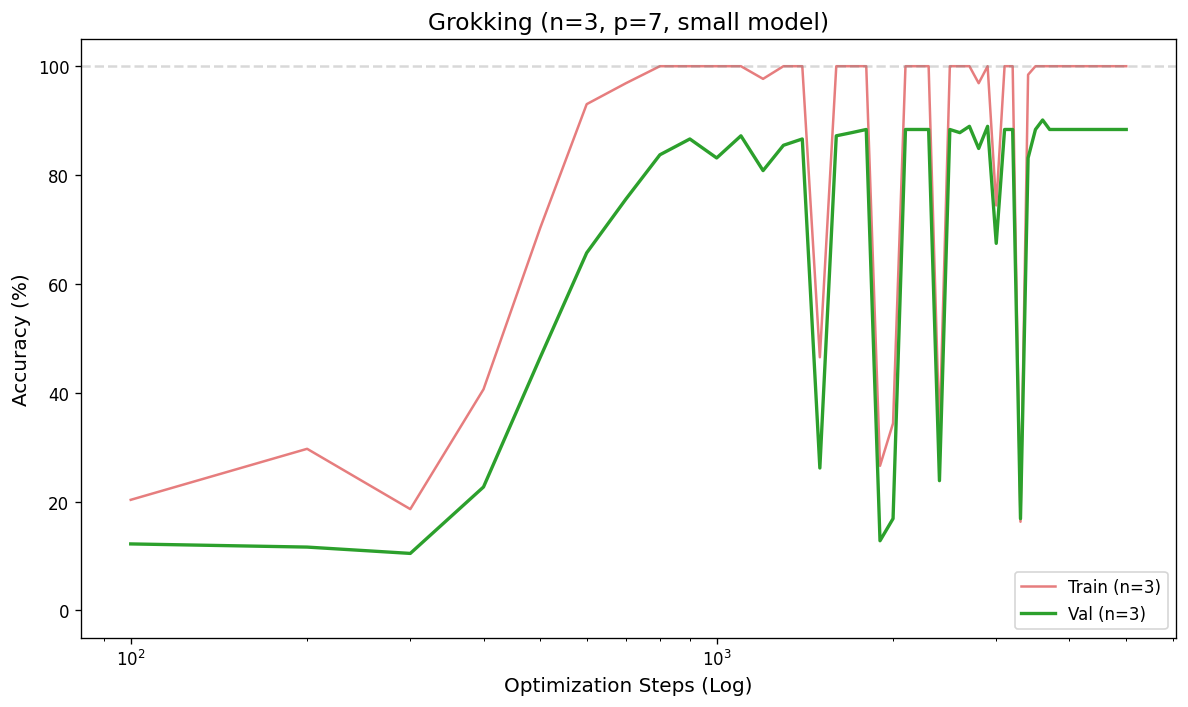

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ==========================================
# 1. 模型定义 (可调整规模)
# ==========================================

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_head=2, n_layer=2, max_len=50, dropout=0.0):
        super().__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pe", self._position_encoding(max_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=4*d_model, 
            dropout=dropout,
            activation='relu',
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.layer_norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)

    def _position_encoding(self, max_len, d_model):
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)

    def forward(self, x):
        seq_len = x.size(1)
        # Causal Mask
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        
        x_emb = self.embedding(x) * math.sqrt(self.d_model)
        x_emb = x_emb + self.pe[:, :seq_len, :]
        out = self.transformer_encoder(x_emb.transpose(0, 1), mask=mask)
        out = out.transpose(0, 1)
        out = self.layer_norm(out)
        logits = self.fc_out(out)
        return logits

# ==========================================
# 2. 全排列数据集 (p=7, n=3 -> 343 samples)
# ==========================================

class FullModularDataset(Dataset):
    def __init__(self, p=7, n_terms=3):
        self.p = p
        self.n_terms = n_terms
        self.plus_token = p
        self.eq_token = p + 1
        self.vocab_size = p + 2
        
        # 生成所有组合 (p^n)
        print(f"Generating dataset: p={p}, n={n_terms} (Total: {p**n_terms})...")
        ranges = [torch.arange(p) for _ in range(n_terms)]
        self.inputs = torch.cartesian_prod(*ranges) 
        
        self.targets = self.inputs.sum(dim=1) % p
        
        N = self.inputs.size(0)
        seq_len = 2 * n_terms
        self.sequences = torch.zeros((N, seq_len), dtype=torch.long)
        
        # 构建序列 [a, +, b, +, c, =]
        for i in range(n_terms):
            self.sequences[:, 2*i] = self.inputs[:, i]
        if seq_len > 1:
            self.sequences[:, 1::2] = self.plus_token
            self.sequences[:, -1] = self.eq_token
            
    def __len__(self):
        return self.sequences.size(0)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# ==========================================
# 3. 实验运行
# ==========================================

def run_experiment(n_terms_list, p=7, train_ratio=0.5, steps=10000, batch_size=64):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    results = {}

    for n in n_terms_list:
        print(f"\n=== Training for n={n} (p={p}) ===")
        
        full_ds = FullModularDataset(p=p, n_terms=n)
        
        # 划分数据集
        total_len = len(full_ds)
        train_len = int(total_len * train_ratio)
        val_len = total_len - train_len
        
        print(f"Train samples: {train_len} | Val samples: {val_len}")
        
        generator = torch.Generator().manual_seed(42)
        train_ds, test_ds = torch.utils.data.random_split(full_ds, [train_len, val_len], generator=generator)
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
        
        # === 缩小后的模型参数 ===
        model = Transformer(
            vocab_size=full_ds.vocab_size,
            d_model=32,   # 缩小: 128 -> 32
            n_head=2,     # 缩小: 4 -> 2
            n_layer=2     # 保持 2 层
        ).to(device)
        
        # 强正则化 Weight Decay = 1.0 (或尝试 2.0)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
        
        # 学习率调度器 (消除尖刺)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
        
        history = {'step': [], 'val_acc': [], 'train_acc': []}
        step_count = 0
        pbar = tqdm(total=steps, desc=f"n={n}")
        
        while step_count < steps:
            for x, y in train_loader:
                if step_count >= steps: break
                
                model.train()
                x, y = x.to(device), y.to(device)
                
                optimizer.zero_grad()
                logits = model(x)
                loss = F.cross_entropy(logits[:, -1, :], y)
                
                loss.backward()
                optimizer.step()
                scheduler.step()
                
                step_count += 1
                
                # 记录 (每 100 步)
                if step_count % 100 == 0:
                    # 训练集准确率 (当前batch近似)
                    with torch.no_grad():
                        train_pred = logits[:, -1, :].argmax(dim=-1)
                        train_acc = (train_pred == y).float().mean().item()
                    
                    # 验证集准确率
                    model.eval()
                    correct = 0
                    total = 0
                    with torch.no_grad():
                        for tx, ty in test_loader:
                            tx, ty = tx.to(device), ty.to(device)
                            out = model(tx)
                            pred = out[:, -1, :].argmax(dim=-1)
                            correct += (pred == ty).sum().item()
                            total += ty.size(0)
                    val_acc = correct / total
                    
                    history['step'].append(step_count)
                    history['train_acc'].append(train_acc)
                    history['val_acc'].append(val_acc)
                    
                    pbar.set_postfix({'tr': f"{train_acc:.2f}", 'val': f"{val_acc:.2f}"})
                    pbar.update(100)
        
        results[n] = history
        pbar.close()
        
    return results

# ==========================================
# 4. 执行与绘图
# ==========================================

if __name__ == "__main__":
    # 实验配置
    P = 7
    N_TERMS_LIST = [3]  # a + b + c
    STEPS = 5000        # 数据集小，5000步相当于很多个epoch了
    
    res = run_experiment(N_TERMS_LIST, p=P, train_ratio=0.5, steps=STEPS, batch_size=64)

    # 绘图
    plt.figure(figsize=(10, 6), dpi=120)
    
    for n, hist in res.items():
        steps = hist['step']
        train_acc = np.array(hist['train_acc']) * 100
        val_acc = np.array(hist['val_acc']) * 100
        
        plt.plot(steps, train_acc, label=f'Train (n={n})', color='#d62728', alpha=0.6)
        plt.plot(steps, val_acc, label=f'Val (n={n})', color='#2ca02c', linewidth=2)

    plt.xscale('log')
    plt.xlabel('Optimization Steps (Log)', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title(f'Grokking (n={N_TERMS_LIST[0]}, p={P}, small model)', fontsize=14)
    plt.legend(loc='lower right')
    plt.ylim(-5, 105)
    plt.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

/home/css/myenv/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Starting training (p=11, epochs=1000)...
Using device: cuda

=== Training for n=3 (p=11) ===
Train: 665 | Val: 666


n=3: 100%|██████████| 1000/1000 [01:03<00:00, 15.63it/s]


Saving results to grokking_results_p11.pkl...
Save complete.
Loading results from grokking_results_p11.pkl...


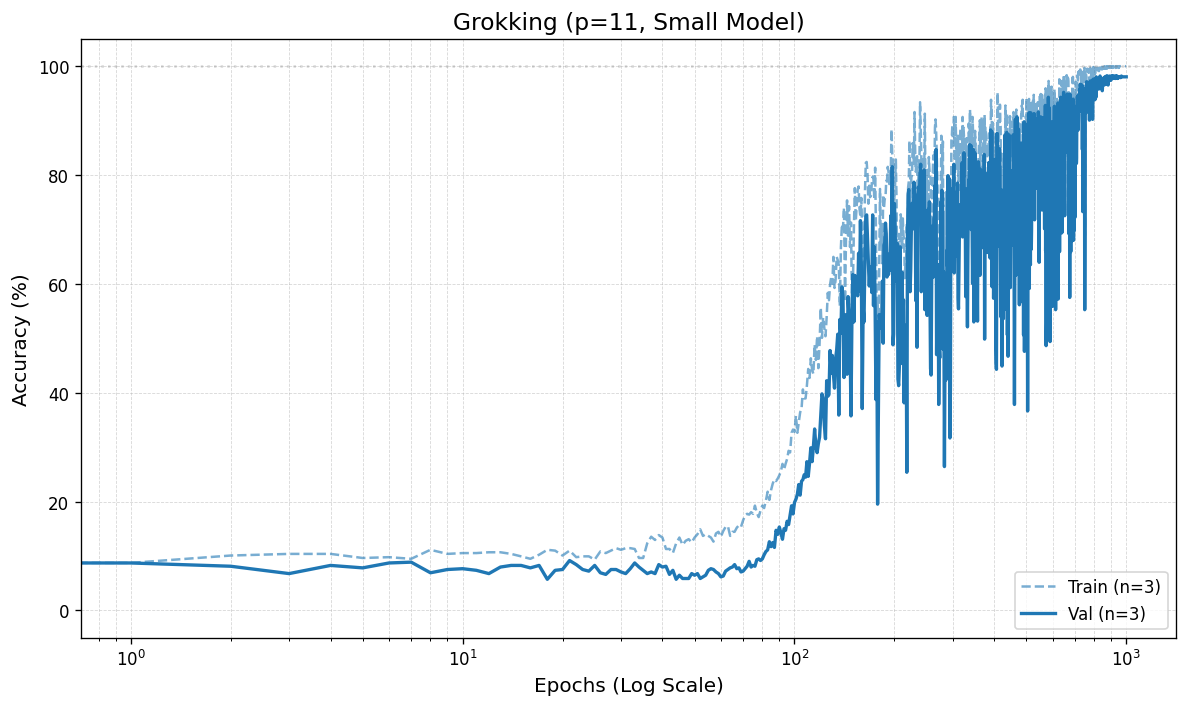

Plot displayed.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import pickle  # 引入 pickle 用于保存数据
import os

# ==========================================
# 1. 模型定义 (小参数规模)
# ==========================================

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_head=2, n_layer=2, max_len=50, dropout=0.0):
        super().__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pe", self._position_encoding(max_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=4*d_model, 
            dropout=dropout,
            activation='relu',
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.layer_norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)

    def _position_encoding(self, max_len, d_model):
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)

    def forward(self, x):
        seq_len = x.size(1)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        
        x_emb = self.embedding(x) * math.sqrt(self.d_model)
        x_emb = x_emb + self.pe[:, :seq_len, :]
        out = self.transformer_encoder(x_emb.transpose(0, 1), mask=mask)
        out = out.transpose(0, 1)
        out = self.layer_norm(out)
        logits = self.fc_out(out)
        return logits

# ==========================================
# 2. 数据集
# ==========================================

class FullModularDataset(Dataset):
    def __init__(self, p=7, n_terms=3):
        self.p = p
        self.n_terms = n_terms
        self.plus_token = p
        self.eq_token = p + 1
        self.vocab_size = p + 2
        
        # 生成所有组合
        ranges = [torch.arange(p) for _ in range(n_terms)]
        self.inputs = torch.cartesian_prod(*ranges) 
        self.targets = self.inputs.sum(dim=1) % p
        
        N = self.inputs.size(0)
        seq_len = 2 * n_terms
        self.sequences = torch.zeros((N, seq_len), dtype=torch.long)
        
        for i in range(n_terms):
            self.sequences[:, 2*i] = self.inputs[:, i]
        if seq_len > 1:
            self.sequences[:, 1::2] = self.plus_token
            self.sequences[:, -1] = self.eq_token
            
    def __len__(self):
        return self.sequences.size(0)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# ==========================================
# 3. 实验运行 (按 Epoch 迭代)
# ==========================================

def run_experiment(n_terms_list, p=7, train_ratio=0.5, max_epochs=2000, batch_size=64):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    results = {}

    for n in n_terms_list:
        print(f"\n=== Training for n={n} (p={p}) ===")
        
        full_ds = FullModularDataset(p=p, n_terms=n)
        
        total_len = len(full_ds)
        train_len = int(total_len * train_ratio)
        val_len = total_len - train_len
        
        print(f"Train: {train_len} | Val: {val_len}")
        
        generator = torch.Generator().manual_seed(42)
        train_ds, test_ds = torch.utils.data.random_split(full_ds, [train_len, val_len], generator=generator)
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
        
        model = Transformer(
            vocab_size=full_ds.vocab_size,
            d_model=32,
            n_head=2,
            n_layer=2
        ).to(device)
        
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs * len(train_loader))
        
        history = {'epoch': [], 'val_acc': [], 'train_acc': []}
        
        # === 按 Epoch 循环 ===
        for epoch in tqdm(range(max_epochs), desc=f"n={n}"):
            model.train()
            train_correct = 0
            train_total = 0
            
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                
                optimizer.zero_grad()
                logits = model(x)
                loss = F.cross_entropy(logits[:, -1, :], y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                
                # 记录训练集统计
                pred = logits[:, -1, :].argmax(dim=-1)
                train_correct += (pred == y).sum().item()
                train_total += y.size(0)
            
            # === 每个 Epoch 结束时进行一次测试 ===
            train_acc = train_correct / train_total
            
            model.eval()
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for tx, ty in test_loader:
                    tx, ty = tx.to(device), ty.to(device)
                    out = model(tx)
                    pred = out[:, -1, :].argmax(dim=-1)
                    val_correct += (pred == ty).sum().item()
                    val_total += ty.size(0)
            val_acc = val_correct / val_total
            
            history['epoch'].append(epoch)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
        
        results[n] = history
        
    return results

# ==========================================
# 4. 执行控制 (保存 -> 加载 -> 绘图)
# ==========================================

if __name__ == "__main__":
    # --- 实验配置 ---
    P = 11
    N_TERMS_LIST = [3] 
    MAX_EPOCHS = 1000 
    BATCH_SIZE = 128
    
    # 文件名
    RESULT_FILE = f"grokking_results_p{P}.pkl"
    
    # 开关：True=重新训练并保存, False=直接加载旧文件绘图
    # 建议：第一次运行设为 True，之后调整画图设为 False
    TRAIN_MODE = True 

    # ==========================
    # Phase 1: 训练与保存
    # ==========================
    if TRAIN_MODE:
        print(f"Starting training (p={P}, epochs={MAX_EPOCHS})...")
        res = run_experiment(
            N_TERMS_LIST, 
            p=P, 
            train_ratio=0.5, 
            max_epochs=MAX_EPOCHS, 
            batch_size=BATCH_SIZE
        )
        
        # 保存数据到 pickle 文件
        print(f"Saving results to {RESULT_FILE}...")
        with open(RESULT_FILE, 'wb') as f:
            pickle.dump(res, f)
        print("Save complete.")
    else:
        print(f"Skipping training. Looking for {RESULT_FILE}...")

    # ==========================
    # Phase 2: 加载与绘图
    # ==========================
    if os.path.exists(RESULT_FILE):
        print(f"Loading results from {RESULT_FILE}...")
        with open(RESULT_FILE, 'rb') as f:
            loaded_results = pickle.load(f)
        
        # 绘图逻辑 (只负责画图)
        plt.figure(figsize=(10, 6), dpi=120)
        
        # 获取颜色循环
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        
        for i, (n, hist) in enumerate(loaded_results.items()):
            epochs = hist['epoch']
            train_acc = np.array(hist['train_acc']) * 100
            val_acc = np.array(hist['val_acc']) * 100
            
            color = colors[i % len(colors)] # 为每个n分配不同的颜色
            
            # 训练集：虚线
            plt.plot(epochs, train_acc, 
                     label=f'Train (n={n})', 
                     color=color, 
                     linestyle='--', 
                     alpha=0.6)
            
            # 测试集：实线
            plt.plot(epochs, val_acc, 
                     label=f'Val (n={n})', 
                     color=color, 
                     linestyle='-', 
                     linewidth=2)

        plt.xscale('log') 
        plt.xlabel('Epochs (Log Scale)', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.title(f'Grokking (p={P}, Small Model)', fontsize=14)
        plt.legend(loc='lower right')
        plt.ylim(-5, 105)
        plt.axhline(y=100, color='gray', linestyle=':', alpha=0.3)
        plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        print("Plot displayed.")
    else:
        print(f"Error: File {RESULT_FILE} not found. Please run with TRAIN_MODE = True first.")

正在生成数据: P=13, N=2, 预计样本数=169...
开始训练: Device=cuda, Total Samples=169
Epoch    0 | Train Acc: 0.0476 | Test Acc: 0.0235
Epoch   10 | Train Acc: 0.5119 | Test Acc: 0.0941
Epoch   20 | Train Acc: 0.9167 | Test Acc: 0.4471
Epoch   30 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch   40 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch   50 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch   60 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch   70 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch   80 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch   90 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  100 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  110 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  120 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  130 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  140 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  150 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  160 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  170 | Train Acc: 1.0000 | Test Acc: 0.5059
Epoch  180 | Train Acc: 1.0000 

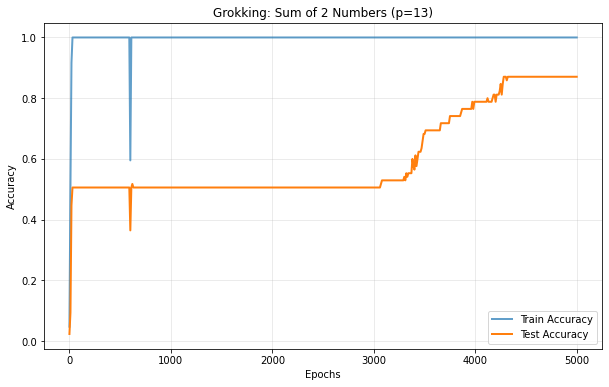

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ===========================
# 1. 超参数设置
# ===========================
# 注意：对于 n=4，如果不减小 p，数据量会指数级爆炸 (97^4 ≈ 8800万)。
# 这里选用 p=23 (23^4 ≈ 28万样本)，既保证了任务有一定难度(Grokking)，又能在单卡上跑完。
P = 13         
N_NUMS = 2      # 输入数字的个数 (a+b+c+d)
D_MODEL = 128   
N_HEAD = 4      
N_LAYER = 1     # 保持单层，利用其损失曲面平滑的特性
LR = 1e-3       
BATCH_SIZE = 1024 # 增大Batch Size以进一步稳定梯度
EPOCHS = 5000   # n=4 比 n=2 难得多，需要更多轮次
TRAIN_RATIO = 0.5 
SEED = 42

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# 2. 数据集生成 (支持任意 n)
# ===========================
def generate_data_n(p, n):
    """生成 n 个数相加的所有组合"""
    print(f"正在生成数据: P={p}, N={n}, 预计样本数={p**n}...")
    # 使用 torch.cartesian_prod 生成所有组合 (注意内存)
    # 对于 p=23, n=4, 显存/内存占用约 10MB，非常安全
    ranges = [torch.arange(p) for _ in range(n)]
    inputs = torch.cartesian_prod(*ranges)
    targets = inputs.sum(dim=1) % p
    return inputs, targets

data_x, data_y = generate_data_n(P, N_NUMS)

# 划分训练集和测试集
total_samples = len(data_x)
train_size = int(total_samples * TRAIN_RATIO)
indices = torch.randperm(total_samples)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

train_dataset = TensorDataset(data_x[train_idx], data_y[train_idx])
test_dataset = TensorDataset(data_x[test_idx], data_y[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# 测试集可能较大，分批测试以防爆显存
test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

# ===========================
# 3. Transformer 模型 (适配 n 输入)
# ===========================
class ModularAdder(nn.Module):
    def __init__(self, p, d_model, n_head, n_layer, n_nums):
        super().__init__()
        self.d_model = d_model
        
        # 1. Embedding
        self.token_emb = nn.Embedding(p, d_model)
        
        # 2. Positional Embedding (长度为 n_nums)
        self.pos_emb = nn.Parameter(torch.randn(1, n_nums, d_model) * 0.02)
        
        # 3. Transformer Encoder (Pre-LN, 单层)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=d_model * 4, 
            dropout=0.0,
            activation='relu',
            batch_first=True,
            norm_first=True # Pre-LN 关键
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        
        # 4. Head
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False)

    def forward(self, idx):
        # idx: (batch, n_nums)
        x = self.token_emb(idx) 
        x = x + self.pos_emb
        
        x = self.transformer(x)
        
        # Mean Pooling: 利用加法对称性，极大地稳定训练
        x = x.mean(dim=1) 
        
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

model = ModularAdder(P, D_MODEL, N_HEAD, N_LAYER, N_NUMS).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.0) # 强正则化
criterion = nn.CrossEntropyLoss()

# ===========================
# 4. 训练循环 (低频采样)
# ===========================
print(f"开始训练: Device={device}, Total Samples={total_samples}")
history = {'step': [], 'train_acc': [], 'test_acc': []}

try:
    for epoch in range(EPOCHS):
        model.train()
        correct = 0
        total = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            
            # 可选：虽然单层模型很稳，但加个裁剪更保险，防止个别Batch梯度爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            
        train_acc = correct / total
        
        # 采样频率：每 50 Epoch 记录一次，过滤震荡，画出平滑曲线
        if epoch % 10 == 0 or epoch == EPOCHS - 1:
            model.eval()
            test_correct = 0
            test_total = 0
            with torch.no_grad():
                for x_test, y_test in test_loader:
                    x_test, y_test = x_test.to(device), y_test.to(device)
                    logits_test = model(x_test)
                    pred_test = logits_test.argmax(dim=-1)
                    test_correct += (pred_test == y_test).sum().item()
                    test_total += y_test.size(0)
            
            test_acc = test_correct / test_total
            
            history['step'].append(epoch)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            
            print(f"Epoch {epoch:4d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
            
            if test_acc > 0.995:
                print(">>> Grokking 达成！模型已完全泛化。")
                break

except KeyboardInterrupt:
    print("训练手动停止")

# ===========================
# 5. 结果可视化
# ===========================
plt.figure(figsize=(10, 6))
plt.plot(history['step'], history['train_acc'], label="Train Accuracy", linewidth=2, alpha=0.7)
plt.plot(history['step'], history['test_acc'], label="Test Accuracy", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Grokking: Sum of {N_NUMS} Numbers (p={P})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


>>> 开始实验: n=2, p=13 (Total Epochs: 5000)
    生成数据中 (p^2)...
    Epoch    0 | Train: 0.0476 | Test: 0.0235
    Epoch  500 | Train: 1.0000 | Test: 0.5059
    Epoch 1000 | Train: 1.0000 | Test: 0.5059
    Epoch 1500 | Train: 1.0000 | Test: 0.5059
    Epoch 2000 | Train: 1.0000 | Test: 0.5059
    Epoch 2500 | Train: 1.0000 | Test: 0.5059
    Epoch 3000 | Train: 1.0000 | Test: 0.5059
    Epoch 3500 | Train: 1.0000 | Test: 0.6824
    Epoch 4000 | Train: 1.0000 | Test: 0.7882
    Epoch 4500 | Train: 1.0000 | Test: 0.8706

>>> 开始实验: n=3, p=13 (Total Epochs: 5000)
    生成数据中 (p^3)...
    Epoch    0 | Train: 0.0738 | Test: 0.0837
    *** Grokking 达成于 Epoch 400 ***

>>> 开始实验: n=4, p=13 (Total Epochs: 5000)
    生成数据中 (p^4)...
    Epoch    0 | Train: 0.0731 | Test: 0.0683
    *** Grokking 达成于 Epoch 460 ***

>>> 所有实验结束，开始绘图...


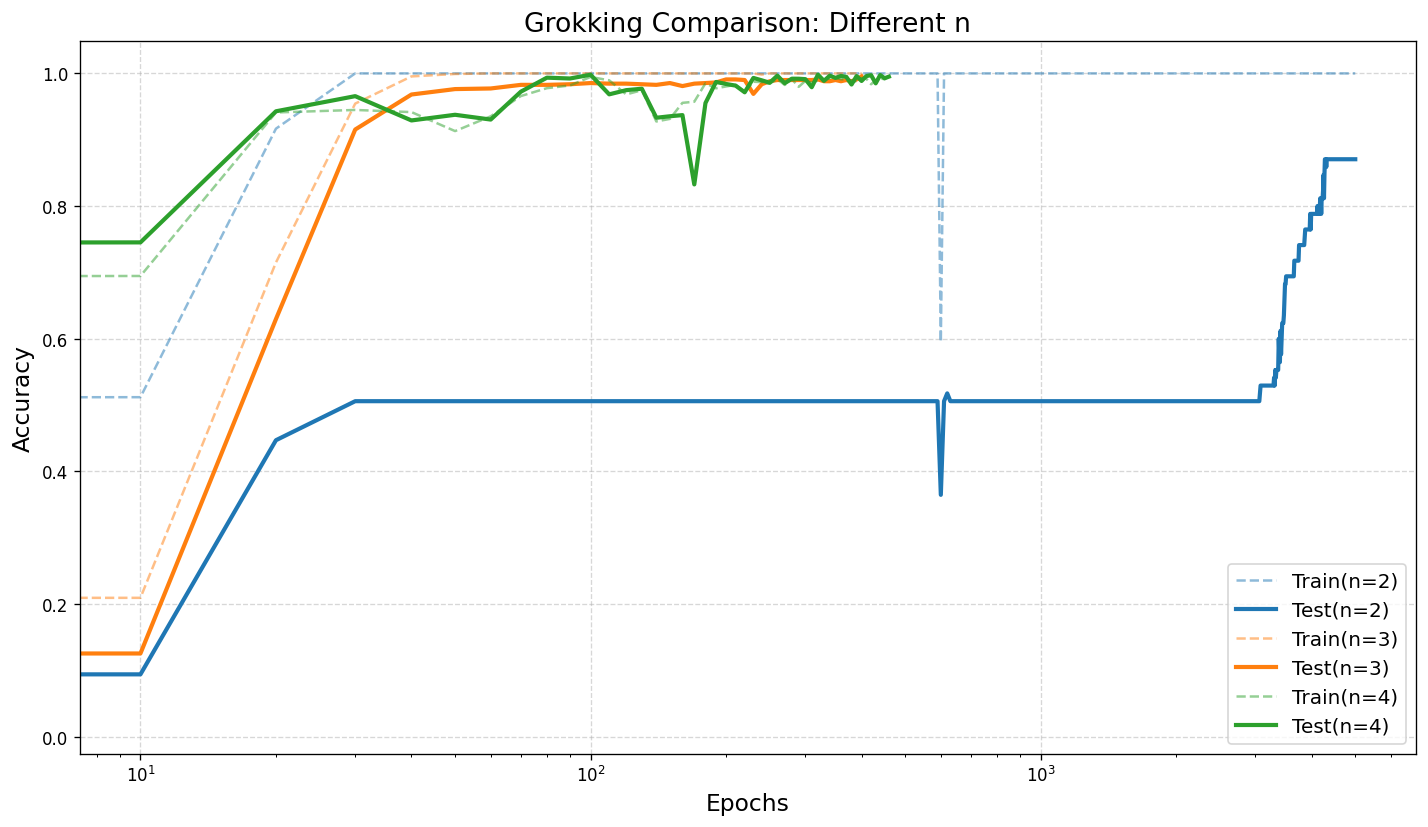

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# 1. 实验配置
# ===========================
# 为每个 n 设定适合的 p，保证既能训练又能发生 Grokking
EXPERIMENT_CONFIGS = [
    {'n': 2, 'p': 13, 'epochs': 5000, 'batch_size': 512},   # n=2 需要大一点的 p
    {'n': 3, 'p': 13, 'epochs': 5000, 'batch_size': 512}
]

D_MODEL = 128   
N_HEAD = 4      
N_LAYER = 1     # 保持单层以获得平滑曲线
LR = 1e-3       
TRAIN_RATIO = 0.5 
SEED = 42
LOG_INTERVAL = 10 # 每50轮记录一次，过滤高频震荡

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# 2. 模型定义 (通用版)
# ===========================
class ModularAdder(nn.Module):
    def __init__(self, p, d_model, n_head, n_layer, n_nums):
        super().__init__()
        self.token_emb = nn.Embedding(p, d_model)
        # 位置编码长度适配 n_nums
        self.pos_emb = nn.Parameter(torch.randn(1, n_nums, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=d_model * 4, 
            dropout=0.0,
            activation='relu',
            batch_first=True,
            norm_first=True # Pre-LN
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False)

    def forward(self, idx):
        x = self.token_emb(idx) + self.pos_emb
        x = self.transformer(x)
        x = x.mean(dim=1) # Mean Pooling
        x = self.ln_f(x)
        return self.head(x)

# ===========================
# 3. 训练与数据生成函数
# ===========================
def run_experiment(config):
    n = config['n']
    p = config['p']
    epochs = config['epochs']
    bs = config['batch_size']
    
    print(f"\n>>> 开始实验: n={n}, p={p} (Total Epochs: {epochs})")
    
    # --- 生成数据 ---
    print(f"    生成数据中 (p^{n})...")
    ranges = [torch.arange(p) for _ in range(n)]
    inputs = torch.cartesian_prod(*ranges)
    targets = inputs.sum(dim=1) % p
    
    # --- 划分数据集 ---
    total_samples = len(inputs)
    train_size = int(total_samples * TRAIN_RATIO)
    indices = torch.randperm(total_samples)
    
    train_ds = TensorDataset(inputs[indices[:train_size]], targets[indices[:train_size]])
    test_ds = TensorDataset(inputs[indices[train_size:]], targets[indices[train_size:]])
    
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)
    
    # --- 初始化模型 ---
    model = ModularAdder(p, D_MODEL, N_HEAD, N_LAYER, n).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.0)
    criterion = nn.CrossEntropyLoss()
    
    # --- 训练循环 ---
    history = {'step': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 梯度裁剪
            optimizer.step()
            
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            
        # --- 记录数据 (低频) ---
        if epoch % LOG_INTERVAL == 0 or epoch == epochs - 1:
            train_acc = correct / total
            
            model.eval()
            test_correct = 0
            test_total = 0
            with torch.no_grad():
                for x_test, y_test in test_loader:
                    x_test, y_test = x_test.to(device), y_test.to(device)
                    logits_t = model(x_test)
                    test_correct += (logits_t.argmax(-1) == y_test).sum().item()
                    test_total += y_test.size(0)
            test_acc = test_correct / test_total
            
            history['step'].append(epoch)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            
            if epoch % 500 == 0:
                print(f"    Epoch {epoch:4d} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")
                
            # 提前停止 (如果完全收敛)
            if test_acc > 0.995 and train_acc > 0.995:
                print(f"    *** Grokking 达成于 Epoch {epoch} ***")
                break
                
    return history

# ===========================
# 4. 主程序与绘图
# ===========================
results = {}
for conf in EXPERIMENT_CONFIGS:
    res = run_experiment(conf)
    results[conf['n']] = res

print("\n>>> 所有实验结束，开始绘图...")

# 设置绘图风格
plt.figure(figsize=(12, 7), dpi=120)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 蓝, 橙, 绿

for i, (n, hist) in enumerate(results.items()):
    c = colors[i % len(colors)]
    steps = hist['step']
    
    # 绘制训练曲线 (虚线)
    plt.plot(steps, hist['train_acc'], 
             linestyle='--', color=c, alpha=0.5, label=f'Train(n={n})')
    
    # 绘制测试曲线 (实线, 加粗)
    plt.plot(steps, hist['test_acc'], 
             linestyle='-', color=c, linewidth=2.5, label=f'Test(n={n})')

plt.title("Grokking Comparison: Different n", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.xscale('log')
plt.ylabel("Accuracy", fontsize=14)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

开始模拟 20x20 网格...


No handles with labels found to put in legend.


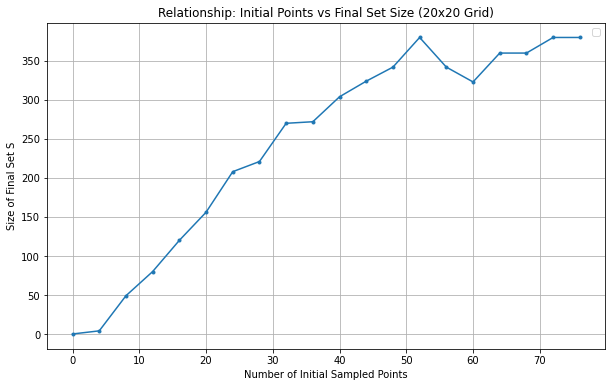

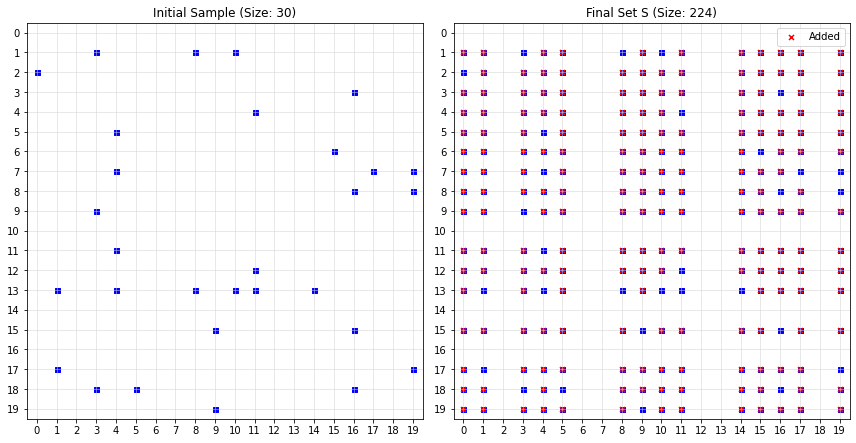

In [10]:
import matplotlib.pyplot as plt
import random
import time
from collections import defaultdict, deque

class GridClosureSimulation:
    def __init__(self, grid_size):
        self.N = grid_size
        
    def get_diagonal_keys(self, r, c):
        """
        返回点 (r, c) 所在的两个对角线标识：
        1. 主对角线 (Main): r - c = constant
        2. 副对角线 (Anti): r + c = constant
        """
        return (r - c, r + c)

    def compute_closure(self, initial_points):
        """
        计算点集的闭包。
        规则：如果 A(i,j) 和 B(m,n) 在同个对角线上，则添加 C(m,j) 和 D(i,n)。
        """
        S = set(initial_points)
        queue = deque(initial_points)
        
        # 使用哈希表记录每条对角线上已存在的点，加速查找
        # key: 对角线ID, value: list of (r, c)
        diag_main = defaultdict(list) # r - c
        diag_anti = defaultdict(list) # r + c
        
        # 初始化哈希表
        for r, c in initial_points:
            d1, d2 = self.get_diagonal_keys(r, c)
            diag_main[d1].append((r, c))
            diag_anti[d2].append((r, c))
            
        while queue:
            curr_r, curr_c = queue.popleft()
            curr_d1, curr_d2 = self.get_diagonal_keys(curr_r, curr_c)
            
            # 寻找同伴点的候选项
            # 1. 检查主对角线上的其他点
            candidates = diag_main[curr_d1] + diag_anti[curr_d2]
            
            for other_r, other_c in candidates:
                if (curr_r, curr_c) == (other_r, other_c):
                    continue
                
                # 根据规则生成新点: (m, j) 和 (i, n)
                # 当前点 (i, j) = (curr_r, curr_c)
                # 伙伴点 (m, n) = (other_r, other_c)
                # 新点1: (other_r, curr_c) -> (m, j)
                # 新点2: (curr_r, other_c) -> (i, n)
                
                new_points = [
                    (other_r, curr_c),
                    (curr_r, other_c)
                ]
                
                for nr, nc in new_points:
                    if (nr, nc) not in S:
                        # 只有在网格范围内的才算(逻辑上生成的点一定在网格内，但作为保险)
                        S.add((nr, nc))
                        queue.append((nr, nc))
                        
                        # 更新对角线索引
                        nd1, nd2 = self.get_diagonal_keys(nr, nc)
                        diag_main[nd1].append((nr, nc))
                        diag_anti[nd2].append((nr, nc))
                        
        return S

    def run_experiment(self, num_samples=50):
        """
        运行实验：分析初始点数与最终点数的关系
        """
        x_axis = [] # 初始点数
        y_axis = [] # 最终点数
        
        # 从 0 到 N*N 逐步增加采样点，步长根据网格大小动态调整
        step = max(1, (self.N * self.N) // 100)
        
        print(f"开始模拟 {self.N}x{self.N} 网格...")
        
        all_coords = [(r, c) for r in range(self.N) for c in range(self.N)]
        
        for k in range(0, self.N * self.N + 1, step):
            # 随机采样 k 个点
            initial_sample = random.sample(all_coords, k)
            
            # 计算闭包
            final_set = self.compute_closure(initial_sample)
            
            x_axis.append(k)
            y_axis.append(len(final_set))
            
        return x_axis, y_axis

    def visualize_grid(self, initial_points, final_points):
        """
        可视化网格对比图
        """
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # 辅助函数：画点
        def plot_points(ax, points, title):
            ax.set_xlim(-0.5, self.N - 0.5)
            ax.set_ylim(-0.5, self.N - 0.5)
            ax.set_aspect('equal')
            ax.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5)
            ax.set_xticks(range(self.N))
            ax.set_yticks(range(self.N))
            ax.invert_yaxis() # 让 (0,0) 在左上角
            ax.set_title(title)
            
            if not points:
                return
            
            y, x = zip(*points) # 注意 matplotlib 也就是 (x, y) 对应 (col, row)
            # 这里为了直观，我们把 row 映射到 y (这就需要invert), col 映射到 x
            ax.scatter(x, y, c='blue', marker='s', s=100 / (self.N/5))

        plot_points(axes[0], initial_points, f"Initial Sample (Size: {len(initial_points)})")
        plot_points(axes[1], final_points, f"Final Set S (Size: {len(final_points)})")
        
        # 标记新增的点
        initial_set = set(initial_points)
        added_points = [p for p in final_points if p not in initial_set]
        if added_points:
             y_add, x_add = zip(*added_points)
             axes[1].scatter(x_add, y_add, c='red', marker='x', s=100 / (self.N/5), label='Added')
             axes[1].legend()

        plt.tight_layout()
        plt.show()

# --- 主程序 ---

# 1. 设置网格大小 (建议不要太大，计算复杂度较高)
GRID_SIZE = 20 
sim = GridClosureSimulation(GRID_SIZE)

# 2. 运行统计分析 (初始点数 vs 最终点数)
x, y = sim.run_experiment()

# 绘制关系曲线
plt.figure(figsize=(10, 6))
plt.plot(x[:20], y[:20], marker='o', markersize=3, linestyle='-')
#plt.plot([0, GRID_SIZE**2], [0, GRID_SIZE**2], 'r--', alpha=0.3, label='y=x (No Growth)')
plt.title(f"Relationship: Initial Points vs Final Set Size ({GRID_SIZE}x{GRID_SIZE} Grid)")
plt.xlabel("Number of Initial Sampled Points")
plt.ylabel("Size of Final Set S")
plt.grid(True)
plt.legend()
plt.show()

# 3. 单次可视化演示 (为了看清规则的效果)
# 随机取一个中间值，通常在 N 左右就能看到明显效果
sample_k = int(GRID_SIZE * 1.5) 
all_pos = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
demo_sample = random.sample(all_pos, sample_k)
demo_result = sim.compute_closure(demo_sample)

sim.visualize_grid(demo_sample, demo_result)

Simulating N=5...
Simulating N=10...
Simulating N=15...
Simulating N=20...
Simulating N=25...
Simulating N=30...
Simulating N=35...
Simulating N=40...
Simulating N=45...
Simulating N=50...
Simulating N=55...
Simulating N=60...
Simulating N=65...
Simulating N=70...
Simulating N=75...
Simulating N=80...
Simulating N=85...
Simulating N=90...
Simulating N=95...
Counts: {5: 10.75, 10: 31.55, 15: 53.4, 20: 68.65, 25: 95.5, 30: 119.0, 35: 145.75, 40: 190.2, 45: 201.75, 50: 257.0, 55: 280.1, 60: 315.15, 65: 343.35, 70: 368.45, 75: 416.6, 80: 436.75, 85: 466.65, 90: 467.1, 95: 534.35}


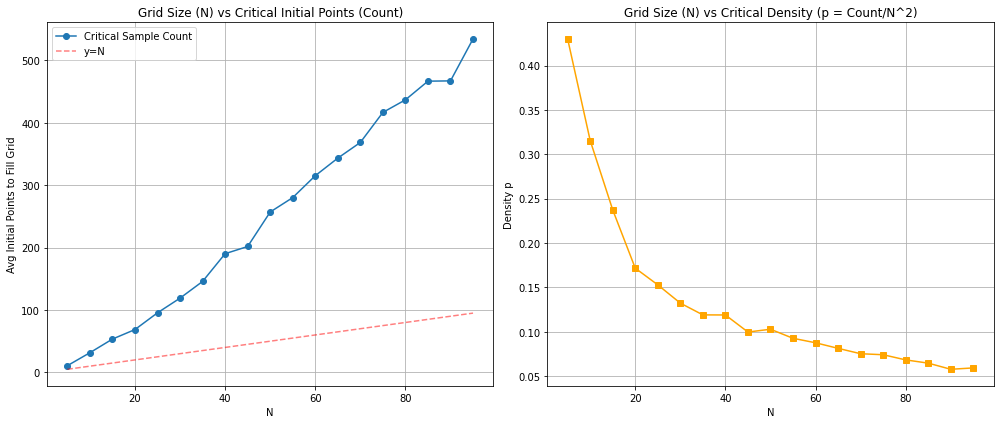

In [12]:
import matplotlib.pyplot as plt
import random
import numpy as np
from collections import defaultdict, deque

class IncrementalGridClosure:
    def __init__(self, n):
        self.N = n
        self.S = set() # Set of all points (sampled + generated)
        self.sampled_points = [] # Keep track of explicitly sampled points
        self.diag_main = defaultdict(list) # r - c
        self.diag_anti = defaultdict(list) # r + c
        self.queue = deque()
        self.total_slots = n * n

    def get_diagonal_keys(self, r, c):
        return (r - c, r + c)

    def add_sample_and_propagate(self, r, c):
        if (r, c) in self.S:
            # If it's already in S (either sampled before or generated), 
            # we still count it as a "sampled step" if the caller wants to count steps.
            # But the logic for closure doesn't change if it's already there.
            # However, usually we sample from available empty spots or just random spots.
            # If we sample a point already in S, it doesn't trigger new propagations *from itself* # (since it was already processed).
            return len(self.S)

        # It's a new point to the set S
        self.S.add((r, c))
        self.queue.append((r, c))
        self.diag_main[r - c].append((r, c))
        self.diag_anti[r + c].append((r, c))
        
        while self.queue:
            curr_r, curr_c = self.queue.popleft()
            d1, d2 = self.get_diagonal_keys(curr_r, curr_c)
            
            # Find neighbors on diagonals
            # Note: In the static version, we iterated all. Here, the lists in diag_main/anti 
            # contain all points currently in S.
            # We need to be careful: the current point is already in the list (added above).
            
            # We can iterate over the lists. 
            # Optimization: We only need to pair 'curr' with 'others'. 
            # Since 'curr' is the one being processed, we iterate existing lists.
            
            candidates = self.diag_main[d1] + self.diag_anti[d2]
            
            for other_r, other_c in candidates:
                if (curr_r, curr_c) == (other_r, other_c):
                    continue
                
                # Generate new points
                # (m, j) and (i, n) from (i, j) and (m, n)
                # p1 = (other_r, curr_c)
                # p2 = (curr_r, other_c)
                
                points_to_check = [
                    (other_r, curr_c),
                    (curr_r, other_c)
                ]
                
                for pr, pc in points_to_check:
                    if (pr, pc) not in self.S:
                        self.S.add((pr, pc))
                        self.queue.append((pr, pc))
                        
                        pd1, pd2 = self.get_diagonal_keys(pr, pc)
                        self.diag_main[pd1].append((pr, pc))
                        self.diag_anti[pd2].append((pr, pc))
        
        return len(self.S)

    def is_full(self):
        return len(self.S) == self.total_slots

def run_simulation(n_values, trials=10):
    results_counts = {}
    results_density = {}
    
    for n in n_values:
        print(f"Simulating N={n}...")
        counts = []
        
        for _ in range(trials):
            grid_sim = IncrementalGridClosure(n)
            
            # Random permutation of all points to simulate sampling without replacement
            # Sampling without replacement is more efficient for finding the threshold
            all_coords = [(r, c) for r in range(n) for c in range(n)]
            random.shuffle(all_coords)
            
            sample_count = 0
            for r, c in all_coords:
                sample_count += 1
                grid_sim.add_sample_and_propagate(r, c)
                if grid_sim.is_full():
                    counts.append(sample_count)
                    break
        
        avg_count = np.mean(counts)
        results_counts[n] = avg_count
        results_density[n] = avg_count / (n * n)
        
    return results_counts, results_density

# Define N values
n_range = range(5, 100, 5) # 5, 10, ..., 50

counts, densities = run_simulation(n_range, trials=20)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: N vs Critical Count
ns = sorted(counts.keys())
ys_count = [counts[n] for n in ns]
ax1.plot(ns, ys_count, 'o-', label='Critical Sample Count')
# Try to fit a curve? It looks linear or Nlogn? Let's just plot.
# Let's add a reference line y=N
ax1.plot(ns, ns, 'r--', label='y=N', alpha=0.5)
ax1.set_title("Grid Size (N) vs Critical Initial Points (Count)")
ax1.set_xlabel("N")
ax1.set_ylabel("Avg Initial Points to Fill Grid")
ax1.legend()
ax1.grid(True)

# Plot 2: N vs Critical Density
ys_density = [densities[n] for n in ns]
ax2.plot(ns, ys_density, 's-', color='orange', label='Critical Density (p)')
ax2.set_title("Grid Size (N) vs Critical Density (p = Count/N^2)")
ax2.set_xlabel("N")
ax2.set_ylabel("Density p")
ax2.grid(True)

plt.tight_layout()
plt.savefig('phase_transition.png')
print("Counts:", counts)

Running Triangle Rule Simulation for N=10...
Running Triangle Rule Simulation for N=20...
Running Triangle Rule Simulation for N=40...
Running Triangle Rule Simulation for N=60...


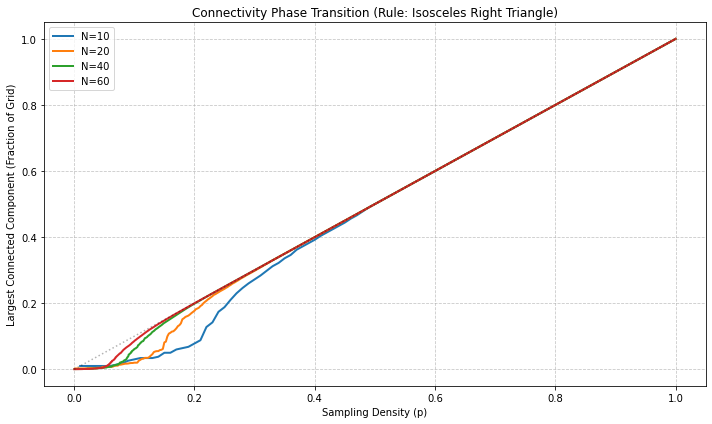

In [14]:
import matplotlib.pyplot as plt
import random
import numpy as np

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.size = [1] * n
        self.max_size = 1 if n > 0 else 0

    def find(self, i):
        if self.parent[i] != i:
            self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i
            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]
            self.max_size = max(self.max_size, self.size[root_i])
            return True
        return False

class TriangleConnectivitySim:
    def __init__(self, grid_n):
        self.N = grid_n
        self.total_points = grid_n * grid_n
        # 记录已采样点的坐标 -> ID 映射
        self.point_to_id = {} 
        # 记录每行、每列拥有的点
        self.rows = {} # key: r, value: list of (c, id)
        self.cols = {} # key: c, value: list of (r, id)
        
        self.uf = UnionFind(self.total_points)

    def get_id(self, r, c):
        return r * self.N + c

    def check_and_connect(self, p1_coord, p1_id, p2_coord, p2_id, p3_coord):
        """
        检查第三个点 p3 是否存在。
        如果存在，说明 p1, p2, p3 构成等腰直角三角形，将它们Union。
        """
        if p3_coord in self.point_to_id:
            p3_id = self.point_to_id[p3_coord]
            # 三点互连
            self.uf.union(p1_id, p2_id)
            self.uf.union(p1_id, p3_id)
            # p2, p3 union is implied, but safe to do
            self.uf.union(p2_id, p3_id)
            return True
        return False

    def add_sample(self, r, c):
        current_id = self.get_id(r, c)
        self.point_to_id[(r, c)] = current_id
        
        # 将新点加入行列索引
        self.rows.setdefault(r, []).append((c, current_id))
        self.cols.setdefault(c, []).append((r, current_id))
        
        # === 搜索三角形逻辑 ===
        # 我们寻找以 (r,c) 为顶点的轴对齐等腰直角三角形 (Axis-Aligned Isosceles Right Triangles)
        # 这种三角形由 3 个点组成。我们需要检查新点是否完成了某个三角形。
        
        # 1. 遍历同行的邻居 H (r, neighbor_c)
        #    距离 d = abs(c - neighbor_c)
        row_neighbors = self.rows[r]
        for (h_c, h_id) in row_neighbors:
            if h_c == c: continue
            d = abs(c - h_c)
            
            # 情况 A: 新点 P 是直角顶点 (Corner)
            # 此时 P 和 H 在同一行。我们需要在 P 的同列上下方距离 d 处找第三个点 V。
            # 检查 (r - d, c) 和 (r + d, c)
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r - d, c))
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r + d, c))
            
            # 情况 B: 邻居 H 是直角顶点 (Corner)
            # 此时 P 和 H 在同一行。我们需要在 H 的同列上下方距离 d 处找第三个点 V。
            # 检查 (r - d, h_c) 和 (r + d, h_c)
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r - d, h_c))
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r + d, h_c))

        # 2. 遍历同列的邻居 V (neighbor_r, c)
        #    距离 d = abs(r - neighbor_r)
        col_neighbors = self.cols[c]
        for (v_r, v_id) in col_neighbors:
            if v_r == r: continue
            d = abs(r - v_r)
            
            # 情况 C: 新点 P 是直角顶点 (Corner)
            # (已在 情况 A 中通过 "同行检查" 覆盖了吗？)
            # 不一定。如果之前的点是先生成的，确实覆盖了。但为了逻辑完备且无遗漏，
            # 这里检查 P 为直角点，V 为同列点，寻找同行的第三点。
            # 检查 (r, c - d) 和 (r, c + d)
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (r, c - d))
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (r, c + d))
            
            # 情况 D: 邻居 V 是直角顶点 (Corner)
            # 此时 P 和 V 在同列。我们需要在 V 的同行左右方距离 d 处找第三点。
            # 检查 (v_r, c - d) 和 (v_r, c + d)
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (v_r, c - d))
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (v_r, c + d))
            
        return self.uf.max_size

def run_triangle_experiment(n_values, trials=5):
    plt.figure(figsize=(10, 6))
    
    for n in n_values:
        print(f"Running Triangle Rule Simulation for N={n}...")
        max_samples = n * n
        aggregated_y = np.zeros(max_samples)
        
        for _ in range(trials):
            sim = TriangleConnectivitySim(n)
            all_coords = [(r, c) for r in range(n) for c in range(n)]
            random.shuffle(all_coords)
            
            y_axis = []
            for i, (r, c) in enumerate(all_coords):
                max_cluster = sim.add_sample(r, c)
                y_axis.append(max_cluster)
            
            aggregated_y += np.array(y_axis)
        
        # 计算平均值
        avg_y = aggregated_y / trials
        
        # 归一化 X 轴 (密度) 和 Y 轴 (最大连通块占比)
        x_norm = np.arange(1, max_samples + 1) / max_samples
        y_norm = avg_y / max_samples
        
        plt.plot(x_norm, y_norm, linewidth=2, label=f'N={n}')

    plt.title('Connectivity Phase Transition (Rule: Isosceles Right Triangle)')
    plt.xlabel('Sampling Density (p)')
    plt.ylabel('Largest Connected Component (Fraction of Grid)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 辅助线
    plt.plot([0, 1], [0, 1], 'k:', alpha=0.3, label='y=x')
    
    plt.tight_layout()
    plt.show()

# 运行不同规模的实验
run_triangle_experiment([10, 20, 40, 60])

Running Triangle Rule Simulation for N=10...
Running Triangle Rule Simulation for N=20...
Running Triangle Rule Simulation for N=30...
Running Triangle Rule Simulation for N=40...


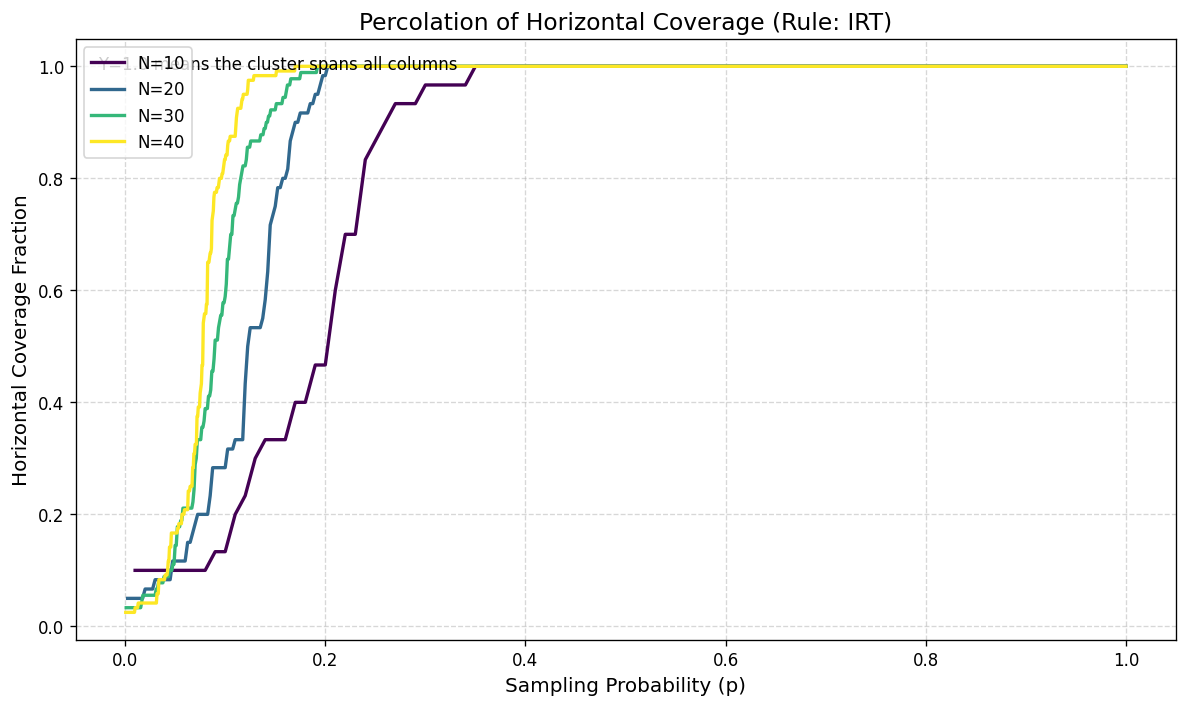

In [15]:
import matplotlib.pyplot as plt
import random
import numpy as np

class UnionFind:
    def __init__(self, n, grid_n):
        self.parent = list(range(n))
        self.size = [1] * n
        # 记录每个集合覆盖的列索引 (using a set is easiest for correctness, though heavier)
        # 初始化时，每个点 (r, c) 只覆盖它自己所在的列 c
        self.cols_covered = [{i % grid_n} for i in range(n)]
        self.max_col_coverage = 1  # 最大覆盖列数
        self.grid_n = grid_n

    def find(self, i):
        if self.parent[i] != i:
            self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j):
        root_i = self.find(i)
        root_j = self.find(j)
        
        if root_i != root_j:
            # Union by size
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i
            
            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]
            
            # Merge column sets
            # 注意：对于非常大的 N，set update 会变慢。
            # 优化方案是只在需要统计时遍历，或者用 bitmask (如果 N < 64)。
            # 对于 N=60，set update 是可以接受的。
            self.cols_covered[root_i].update(self.cols_covered[root_j])
            
            # 清理被合并的子集的内存 (可选)
            self.cols_covered[root_j] = set()
            
            current_coverage = len(self.cols_covered[root_i])
            self.max_col_coverage = max(self.max_col_coverage, current_coverage)
            
            return True
        return False

class TriangleConnectivitySim:
    def __init__(self, grid_n):
        self.N = grid_n
        self.total_points = grid_n * grid_n
        self.point_to_id = {} 
        self.rows = {} 
        self.cols = {} 
        self.uf = UnionFind(self.total_points, grid_n)

    def get_id(self, r, c):
        return r * self.N + c

    def check_and_connect(self, p1_coord, p1_id, p2_coord, p2_id, p3_coord):
        if p3_coord in self.point_to_id:
            p3_id = self.point_to_id[p3_coord]
            self.uf.union(p1_id, p2_id)
            self.uf.union(p1_id, p3_id)
            self.uf.union(p2_id, p3_id)
            return True
        return False

    def add_sample(self, r, c):
        current_id = self.get_id(r, c)
        self.point_to_id[(r, c)] = current_id
        
        self.rows.setdefault(r, []).append((c, current_id))
        self.cols.setdefault(c, []).append((r, current_id))
        
        # === 搜索三角形逻辑 (保持不变) ===
        row_neighbors = self.rows[r]
        for (h_c, h_id) in row_neighbors:
            if h_c == c: continue
            d = abs(c - h_c)
            # 检查同列上下
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r - d, c))
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r + d, c))
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r - d, h_c))
            self.check_and_connect((r, c), current_id, (r, h_c), h_id, (r + d, h_c))

        col_neighbors = self.cols[c]
        for (v_r, v_id) in col_neighbors:
            if v_r == r: continue
            d = abs(r - v_r)
            # 检查同行左右
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (r, c - d))
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (r, c + d))
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (v_r, c - d))
            self.check_and_connect((r, c), current_id, (v_r, c), v_id, (v_r, c + d))
            
        return self.uf.max_col_coverage

def run_triangle_experiment(n_values, trials=5):
    plt.figure(figsize=(10, 6), dpi=120)
    colors = plt.cm.viridis(np.linspace(0, 1, len(n_values)))
    
    for idx, n in enumerate(n_values):
        print(f"Running Triangle Rule Simulation for N={n}...")
        max_samples = n * n
        aggregated_coverage = np.zeros(max_samples)
        
        for _ in range(trials):
            sim = TriangleConnectivitySim(n)
            all_coords = [(r, c) for r in range(n) for c in range(n)]
            random.shuffle(all_coords)
            
            coverage_history = []
            for r, c in all_coords:
                max_cov = sim.add_sample(r, c)
                coverage_history.append(max_cov)
            
            aggregated_coverage += np.array(coverage_history)
        
        avg_coverage = aggregated_coverage / trials
        
        # X轴: 采样比例 p
        p_axis = np.arange(1, max_samples + 1) / max_samples
        # Y轴: 水平覆盖率 (Max Columns Covered / N)
        coverage_norm = avg_coverage / n
        
        plt.plot(p_axis, coverage_norm, linewidth=2, color=colors[idx], label=f'N={n}')

    plt.title('Percolation of Horizontal Coverage (Rule: IRT)', fontsize=14)
    plt.xlabel('Sampling Probability (p)', fontsize=12)
    plt.ylabel('Horizontal Coverage Fraction', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 标注说明
    plt.text(0.02, 0.95, "Y=1.0 means the cluster spans all columns", transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()

# 建议稍微减小 N 进行测试，因为 set update 操作比较耗时
run_triangle_experiment([10, 20, 30, 40], trials=3)

开始模拟 (无放回采样模式 - Without Replacement)...
注意：当 n 接近 p 时，收敛速度会显著加快。

正在计算 p=17 (目标秩 15)...
测试的 n 值序列: [2, 3, 4, 5, 6, 7, 8, 9]


p=17 计算完成。在 n=9 时平均 m = 40.55

正在计算 p=23 (目标秩 21)...
测试的 n 值序列: [2, 3, 4, 5, 6, 7, 8, 9]
p=23 计算完成。在 n=9 时平均 m = 58.90


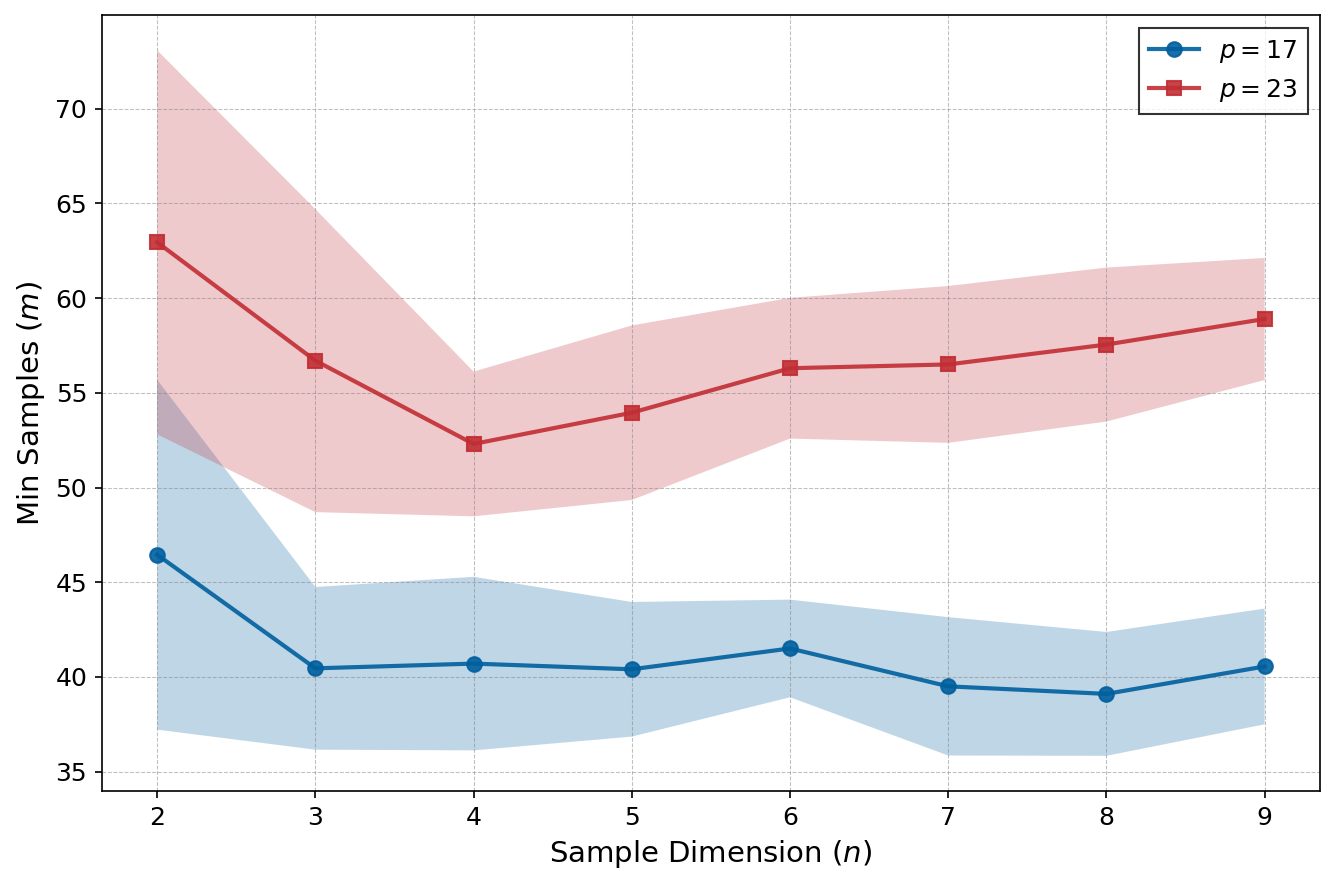

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sys

# 增加递归深度限制，防止在极端情况下（如n=p且p较大时）链式配对逻辑过深
sys.setrecursionlimit(5000)

# --- 1. 核心模拟函数 (改为无放回采样) ---
def get_rank(H, threshold=1e-5):
    """计算矩阵的秩"""
    # 使用 eigvalsh 处理实对称矩阵更稳定
    eigvals = np.linalg.eigvalsh(H)
    return np.sum(np.abs(eigvals) > threshold)

def simulate_min_m_without_replacement(p, n, target_rank, max_m_limit=1000):
    """
    寻找最小的 m 使得 Hessian 秩达到 target_rank (无放回模式)
    """
    # 硬性约束检查
    if n > p:
        raise ValueError(f"无放回采样要求 n <= p。当前 n={n}, p={p}")

    groups = defaultdict(list)
    
    # 增量增加 m
    # 对于无放回采样，当 n 接近 p 时收敛极快，max_m_limit 可以设小一点
    for m in range(1, max_m_limit + 1):
        # --- 【核心修改】 ---
        # 使用 choice 并设置 replace=False 进行无放回采样
        new_sample = np.random.choice(p, size=n, replace=False)
        # -------------------
        
        s_sum = np.sum(new_sample)
        groups[s_sum].append(new_sample)
        
        # 优化：样本数太少时不可能达到目标秩，跳过计算
        if m < target_rank:
            continue
            
        # 构建全局 Hessian
        H_total = np.zeros((p, p))
        
        # 遍历所有组进行配对
        for g_sum, group in groups.items():
            a = len(group)
            if a < 2: continue # 至少需要2个样本才能形成非零配对
            
            # 链式配对 (s0, s1), (s1, s2), ..., (s_last, s0)
            for i in range(a):
                s1 = group[i]
                s2 = group[(i + 1) % a]
                
                # 构造系数向量 c
                c = np.zeros(p)
                np.add.at(c, s1, 1)
                np.add.at(c, s2, -1)
                
                # 累加 Hessian 项
                H_total += 2 * np.outer(c, c)
        
        # 检查秩是否达标
        if get_rank(H_total) >= target_rank:
            return m
            
    return max_m_limit

# --- 2. 实验控制与数据收集 (调整了 n 的范围) ---
def run_comparison_modified():
    p_list = [17, 23]
    trials = 20  # 重复次数，用于计算均值和方差
    
    data = {}
    
    print("开始模拟 (无放回采样模式 - Without Replacement)...")
    print("注意：当 n 接近 p 时，收敛速度会显著加快。")
    
    for p in p_list:
        target_rank = p - 2
        means = []
        stds = []
        
        # --- 【关键调整】 ---
        # n 必须小于等于 p。我们生成一个从 2 到 p 的测试序列。
        # 在小数值密集采样，大数值稀疏采样，最后必须包含 p 本身。
        n_values_raw = list(range(2, 10))
        # 确保去重且排序，并剔除任何意外超过 p 的值
        n_values = sorted(list(set([n for n in n_values_raw if n <= p])))
        
        print(f"\n正在计算 p={p} (目标秩 {target_rank})...")
        print(f"测试的 n 值序列: {n_values}")
        
        for n in n_values:
            m_results = []
            # print(f"  Running n={n}...", end='\r') # 进度提示
            for _ in range(trials):
                m = simulate_min_m_without_replacement(p, n, target_rank)
                m_results.append(m)
            
            means.append(np.mean(m_results))
            stds.append(np.std(m_results))
            
        data[p] = {
            'n': n_values,
            'mean': np.array(means),
            'std': np.array(stds)
        }
        print(f"p={p} 计算完成。在 n={n_values[-1]} 时平均 m = {means[-1]:.2f}")
    
    return data

# --- 3. 绘图 (保持论文质量格式) ---
def plot_paper_quality_v2(data):
    plt.figure(figsize=(9, 6), dpi=150)
    
    styles = {
        17: {'color': '#005f9e', 'marker': 'o', 'label': r'$p=17$'},
        23: {'color': '#c12e34', 'marker': 's', 'label': r'$p=23$'}
    }
    
    for p, dataset in data.items():
        n = np.array(dataset['n'])
        mean = dataset['mean']
        std = dataset['std']
        style = styles[p]
        
        # 绘制主曲线
        plt.plot(n, mean, 
                 color=style['color'], marker=style['marker'], markersize=7, 
                 linewidth=2, label=style['label'], alpha=0.9)
        
        # 绘制误差带
        plt.fill_between(n, mean - std, mean + std, 
                         color=style['color'], alpha=0.25, edgecolor=None)
        
        # # 标注终点 (n=p 时)
        # plt.annotate(f"{mean[-1]:.1f}", 
        #              xy=(n[-1], mean[-1]), xytext=(n[-1]-2, mean[-1]+20),
        #              arrowprops=dict(arrowstyle="->", color=style['color']),
        #              color=style['color'], fontweight='bold')

    # 坐标轴与标签
    plt.xlabel(r'Sample Dimension ($n$)', fontsize=14)
    plt.ylabel(r'Min Samples ($m$)', fontsize=14)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    plt.legend(fontsize=12, frameon=True, fancybox=False, edgecolor='black', loc='upper right')
    
    # 设置x轴范围略微宽一点以显示末端标签
    max_p = max(data.keys())
    
    plt.tight_layout()
    plt.show()

# --- 执行 ---
# 这个模拟比有放回的要快很多，特别是在 n 较大时
experiment_data_v2 = run_comparison_modified()
plot_paper_quality_v2(experiment_data_v2)


>>> 开始实验: n=4, p=17
    生成数据中 (p^4 = 83521)...
    固定训练集大小: 1734 (占总数据 2.08%)


/home/css/myenv/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


    Epoch     0 | Train: 0.0663 | Test: 0.0572
    Epoch  1000 | Train: 0.9988 | Test: 0.2430
    Epoch  2000 | Train: 0.9925 | Test: 0.3817
    *** Grokking 达成于 Epoch 2850 ***

>>> 所有实验结束，开始绘图...


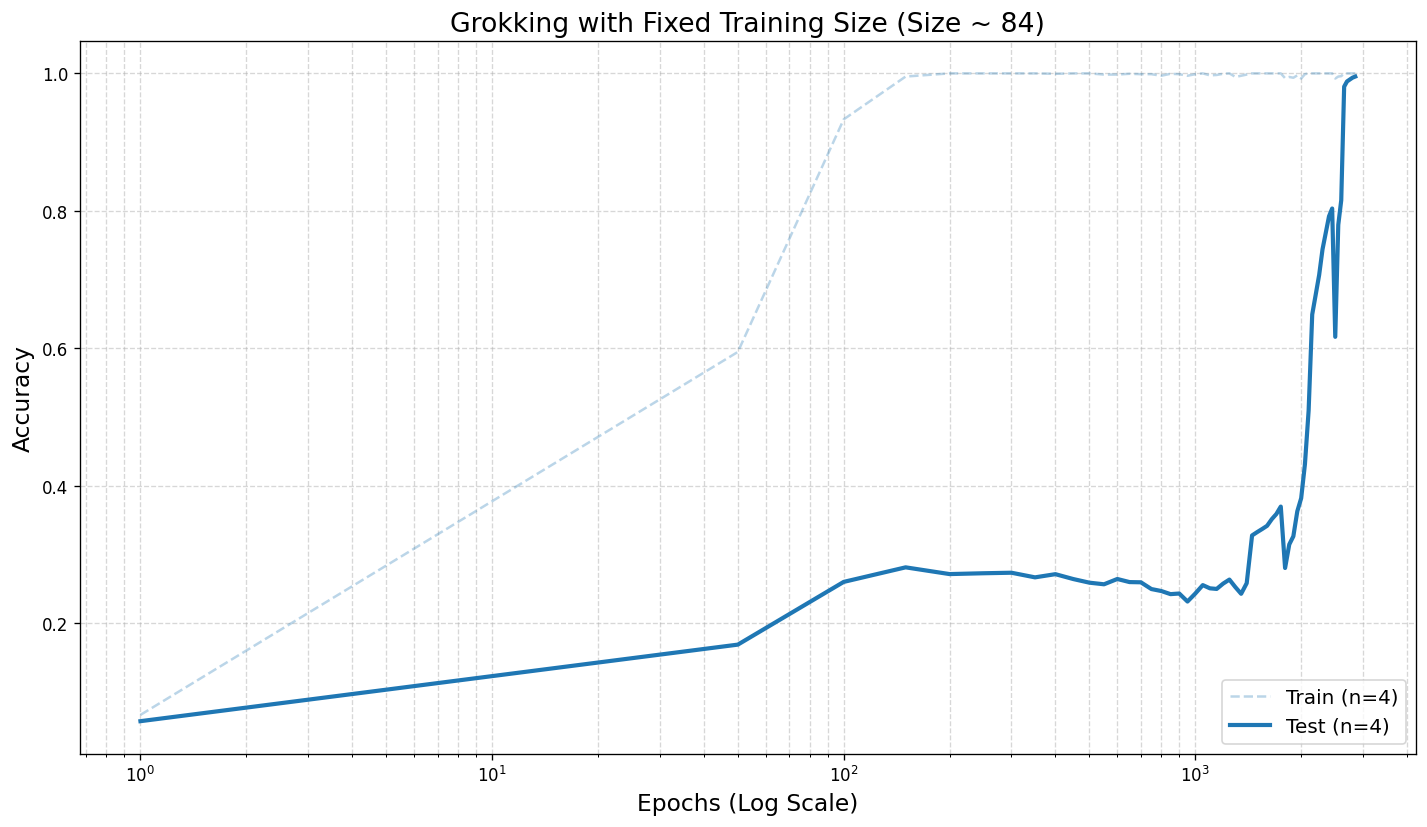

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# 1. 实验配置
# ===========================
EXPERIMENT_CONFIGS = [
    {'n': 4, 'p': 17, 'epochs': 10000, 'batch_size': 512}, # 增加 epoch 以应对极稀疏数据
    # {'n': 3, 'p': 17, 'epochs': 10000, 'batch_size': 512},
    # {'n': 4, 'p': 17, 'epochs': 10000, 'batch_size': 512},
]

D_MODEL = 128   
N_HEAD = 4      
N_LAYER = 1     
LR = 1e-3       
# TRAIN_RATIO = 0.5  <-- 不再使用比例
SEED = 42
LOG_INTERVAL = 50 

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# 2. 模型定义 (通用版)
# ===========================
class ModularAdder(nn.Module):
    def __init__(self, p, d_model, n_head, n_layer, n_nums):
        super().__init__()
        self.token_emb = nn.Embedding(p, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, n_nums, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=d_model * 4, 
            dropout=0.0,
            activation='relu',
            batch_first=True,
            norm_first=True 
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False)

    def forward(self, idx):
        x = self.token_emb(idx) + self.pos_emb
        x = self.transformer(x)
        x = x.mean(dim=1) 
        x = self.ln_f(x)
        return self.head(x)

# ===========================
# 3. 训练与数据生成函数
# ===========================
def run_experiment(config):
    n = config['n']
    p = config['p']
    epochs = config['epochs']
    bs = config['batch_size']
    
    # === 关键修改：计算固定的训练集大小 ===
    # 目标训练集大小固定为 p^2 / 2
    target_train_size = int((p**2)*6)
    
    print(f"\n>>> 开始实验: n={n}, p={p}")
    print(f"    生成数据中 (p^{n} = {p**n})...")
    ranges = [torch.arange(p) for _ in range(n)]
    inputs = torch.cartesian_prod(*ranges)
    targets = inputs.sum(dim=1) % p
    
    total_samples = len(inputs)
    
    # 确保训练集大小不超过总样本数 (对 n>=2 肯定满足)
    train_size = min(target_train_size, total_samples)
    val_size = total_samples - train_size
    
    print(f"    固定训练集大小: {train_size} (占总数据 {train_size/total_samples:.2%})")
    
    # --- 划分数据集 ---
    indices = torch.randperm(total_samples)
    train_ds = TensorDataset(inputs[indices[:train_size]], targets[indices[:train_size]])
    test_ds = TensorDataset(inputs[indices[train_size:]], targets[indices[train_size:]])
    
    # Batch size 不能超过训练集大小
    actual_bs = min(bs, train_size)
    train_loader = DataLoader(train_ds, batch_size=actual_bs, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)
    
    # --- 初始化模型 ---
    model = ModularAdder(p, D_MODEL, N_HEAD, N_LAYER, n).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.0)
    criterion = nn.CrossEntropyLoss()
    
    # --- 训练循环 ---
    history = {'step': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
            optimizer.step()
            
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            
        # --- 记录数据 ---
        if epoch % LOG_INTERVAL == 0 or epoch == epochs - 1:
            train_acc = correct / total
            
            model.eval()
            test_correct = 0
            test_total = 0
            with torch.no_grad():
                for x_test, y_test in test_loader:
                    x_test, y_test = x_test.to(device), y_test.to(device)
                    logits_t = model(x_test)
                    test_correct += (logits_t.argmax(-1) == y_test).sum().item()
                    test_total += y_test.size(0)
            test_acc = test_correct / test_total
            
            # 处理 step=0
            record_step = epoch if epoch > 0 else 1
            
            history['step'].append(record_step)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            
            if epoch % 1000 == 0:
                print(f"    Epoch {epoch:5d} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")
                
            if test_acc > 0.995 and train_acc > 0.995:
                print(f"    *** Grokking 达成于 Epoch {epoch} ***")
                break
                
    return history

# ===========================
# 4. 主程序与绘图
# ===========================
results = {}
for conf in EXPERIMENT_CONFIGS:
    res = run_experiment(conf)
    results[conf['n']] = res

print("\n>>> 所有实验结束，开始绘图...")

plt.figure(figsize=(12, 7), dpi=120)
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # 蓝, 橙, 红

for i, (n, hist) in enumerate(results.items()):
    c = colors[i % len(colors)]
    steps = hist['step']
    
    # 绘制训练曲线 (虚线)
    plt.plot(steps, hist['train_acc'], 
             linestyle='--', color=c, alpha=0.3, label=f'Train (n={n})')
    
    # 绘制测试曲线 (实线)
    plt.plot(steps, hist['test_acc'], 
             linestyle='-', color=c, linewidth=2.5, label=f'Test (n={n})')

plt.xscale('log')
plt.title(f"Grokking with Fixed Training Size (Size ~ {int((13**2)/2)})", fontsize=16)
plt.xlabel("Epochs (Log Scale)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# 1. 实验配置
# ===========================
SEARCH_CONFIGS = [
    {'n': 5, 'p': 17},  # 41^2 = 1681 样本
    {'n': 3, 'p': 17},  # 13^3 = 2197 样本
    {'n': 4, 'p': 17},   # 7^4  = 2401 样本
]

# 比例生成：从 0.4 开始，向下递减，步长 0.025 (2.5%)
# 范围: [0.400, 0.375, 0.350, ..., 0.025]
START_RATIO = 0.5
END_RATIO = 0.001
STEP = 0.001
TEST_RATIOS = np.arange(START_RATIO, END_RATIO, -STEP).tolist()

# 固定参数
D_MODEL = 128   
N_HEAD = 4      
N_LAYER = 1     
LR = 1e-3       
MAX_EPOCHS = 3000
TARGET_ACC = 0.95
SEED = 42

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# 2. 模型定义
# ===========================
class ModularAdder(nn.Module):
    def __init__(self, p, d_model, n_head, n_layer, n_nums):
        super().__init__()
        self.token_emb = nn.Embedding(p, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, n_nums, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=d_model * 4, 
            dropout=0.0,
            activation='relu',
            batch_first=True,
            norm_first=True 
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False)

    def forward(self, idx):
        x = self.token_emb(idx) + self.pos_emb
        x = self.transformer(x)
        x = x.mean(dim=1) 
        x = self.ln_f(x)
        return self.head(x)

# ===========================
# 3. 训练函数
# ===========================
def train_and_evaluate(n, p, ratio):
    # --- 生成数据 ---
    ranges = [torch.arange(p) for _ in range(n)]
    inputs = torch.cartesian_prod(*ranges)
    targets = inputs.sum(dim=1) % p
    
    total_samples = len(inputs)
    train_size = int(total_samples * ratio)
    
    # 极小样本保护
    if train_size < 5:
        return False, train_size, total_samples

    indices = torch.randperm(total_samples)
    train_ds = TensorDataset(inputs[indices[:train_size]], targets[indices[:train_size]])
    test_ds = TensorDataset(inputs[indices[train_size:]], targets[indices[train_size:]])
    
    bs = min(512, train_size)
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)
    
    # --- 模型与优化 ---
    model = ModularAdder(p, D_MODEL, N_HEAD, N_LAYER, n).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.0)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

    # --- 训练循环 ---
    success = False
    
    # 进度条显示可以简化，只打印关键点
    print(f"    [训练] 样本数: {train_size} | ", end="", flush=True)

    for epoch in range(MAX_EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        scheduler.step()

        # 检测泛化
        if (epoch + 1) % 200 == 0 or epoch == MAX_EPOCHS - 1:
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for x_test, y_test in test_loader:
                    x_test, y_test = x_test.to(device), y_test.to(device)
                    pred = model(x_test).argmax(-1)
                    correct += (pred == y_test).sum().item()
                    total += y_test.size(0)
            acc = correct / total
            
            # 达到目标，提前成功
            if acc >= TARGET_ACC:
                print(f"✔ 成功 (Epoch {epoch}, Acc {acc:.1%})")
                success = True
                break
    
    if not success:
        print(f"✘ 失败 (Max Acc {acc:.1%})")
        
    return success, train_size, total_samples

# ===========================
# 4. 主搜索循环
# ===========================
final_results = []

print(f"=== 开始搜索最小样本量 (Start Ratio={START_RATIO}, Step={STEP}, MaxEpochs={MAX_EPOCHS}) ===\n")

for config in SEARCH_CONFIGS:
    n = config['n']
    p = config['p']
    print(f">>> 正在测试 n={n}, p={p} (Total Data: {p**n})")
    
    best_result = None
    
    for ratio in TEST_RATIOS:
        print(f"  > 尝试比例 {ratio:.3f}: ", end="")
        
        is_success, train_size, total = train_and_evaluate(n, p, ratio)
        
        if is_success:
            # 成功了，记录当前为“已知最小值”，并继续尝试更小的
            best_result = {
                'n': n,
                'p': p,
                'min_ratio': ratio,
                'min_samples': train_size,
                'total_samples': total
            }
        else:
            # 失败了，说明已经跌破了所需的最小数据量
            # 停止当前 n 的搜索，因为再小肯定也不行
            print(f"  > 比例 {ratio:.3f} 失败，停止向下搜索。")
            break
    
    if best_result:
        final_results.append(best_result)
        print(f"  *** n={n} 的最小比例锁定为: {best_result['min_ratio']:.3f} (样本数 {best_result['min_samples']}) ***\n")
    else:
        # 如果 0.4 起步就失败
        final_results.append({
            'n': n, 'p': p, 'min_ratio': f">{START_RATIO}", 'min_samples': "N/A", 'total_samples': p**n
        })
        print(f"  *** n={n} 在起始比例 {START_RATIO} 即失败 ***\n")

# ===========================
# 5. 结果汇总输出
# ===========================
print("\n" + "="*60)
print(f"{'n':<5} | {'p':<5} | {'Total':<8} | {'Min Ratio':<12} | {'Min Samples':<12}")
print("-" * 60)
for res in final_results:
    if isinstance(res['min_ratio'], float):
        ratio_str = f"{res['min_ratio']:.1%}"
    else:
        ratio_str = str(res['min_ratio'])
        
    print(f"{res['n']:<5} | {res['p']:<5} | {res['total_samples']:<8} | {ratio_str:<12} | {res['min_samples']:<12}")
print("-" * 60)

=== 开始搜索最小样本量 (Start Ratio=0.01, Step=0.001, MaxEpochs=3000) ===

>>> 正在测试 n=5, p=17 (Total Data: 1419857)
  > 尝试比例 0.010:     [训练] 样本数: 14198 | ✔ 成功 (Epoch 199, Acc 99.7%)
  > 尝试比例 0.009:     [训练] 样本数: 12778 | ✔ 成功 (Epoch 199, Acc 99.1%)
  > 尝试比例 0.008:     [训练] 样本数: 11358 | ✔ 成功 (Epoch 199, Acc 98.8%)
  > 尝试比例 0.007:     [训练] 样本数: 9938 | ✔ 成功 (Epoch 399, Acc 98.5%)
  > 尝试比例 0.006:     [训练] 样本数: 8519 | ✔ 成功 (Epoch 599, Acc 99.5%)
  > 尝试比例 0.005:     [训练] 样本数: 7099 | ✔ 成功 (Epoch 1799, Acc 98.5%)
  > 尝试比例 0.004:     [训练] 样本数: 5679 | ✘ 失败 (Max Acc 7.8%)
  > 比例 0.004 失败，停止向下搜索。
  *** n=5 的最小比例锁定为: 0.005 (样本数 7099) ***

>>> 正在测试 n=3, p=17 (Total Data: 4913)
  > 尝试比例 0.010:     [训练] 样本数: 49 | ✘ 失败 (Max Acc 6.4%)
  > 比例 0.010 失败，停止向下搜索。
  *** n=3 在起始比例 0.01 即失败 ***

>>> 正在测试 n=4, p=17 (Total Data: 83521)
  > 尝试比例 0.010:     [训练] 样本数: 835 | ✘ 失败 (Max Acc 17.2%)
  > 比例 0.010 失败，停止向下搜索。
  *** n=4 在起始比例 0.01 即失败 ***


n     | p     | Total    | Min Ratio    | Min Samples 
-----------------------

Plot saved.
n     | p     | Total    | Ratio      | Samples   
--------------------------------------------------
2     | 17    | 289      | 0.4        | 115       
3     | 17    | 4913     | 0.2        | 982       
4     | 17    | 83521    | 0.05       | 4176      


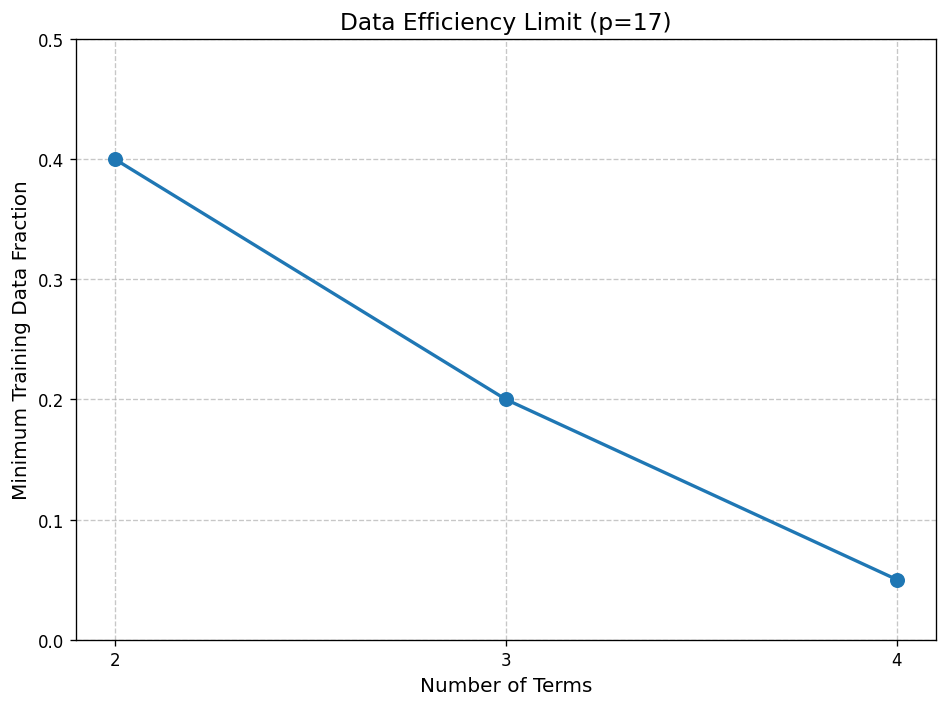

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data
p = 17
ns = [2, 3, 4]
ratios = [0.4, 0.2, 0.05]

# Calculations
total_samples = [p**n for n in ns]
min_samples = [int(t * r) for t, r in zip(total_samples, ratios)]

# Plotting
plt.figure(figsize=(8, 6), dpi=120)

# Plot line and points
plt.plot(ns, ratios, marker='o', linestyle='-', linewidth=2, markersize=8, color='#1f77b4', label='Minimum Data Fraction')

# # Annotate with sample sizes
# for i, (n, r, s, t) in enumerate(zip(ns, ratios, min_samples, total_samples)):
#     label = f"{r:.0%}\n({s}/{t})"
#     plt.annotate(label, 
#                  (n, r), 
#                  textcoords="offset points", 
#                  xytext=(0, 10), 
#                  ha='center', 
#                  fontsize=10,
#                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1f77b4", alpha=0.8))

# Formatting
plt.title(f"Data Efficiency Limit (p={p})", fontsize=14)
plt.xlabel("Number of Terms", fontsize=12)
plt.ylabel("Minimum Training Data Fraction", fontsize=12)
plt.xticks(ns)
plt.ylim(0, 0.5)  # Adjust ylim to make room for annotations
plt.grid(True, linestyle='--', alpha=0.7)

# Add a table at the bottom or display it in text? 
# The user asked for "draw image... and corresponding sample numbers". 
# The plot annotations cover the visual part. I will also print the text.

plt.tight_layout()
plt.savefig('data_efficiency_p17.png')
print("Plot saved.")

# Print the table for the text response
print(f"{'n':<5} | {'p':<5} | {'Total':<8} | {'Ratio':<10} | {'Samples':<10}")
print("-" * 50)
for n, t, r, s in zip(ns, total_samples, ratios, min_samples):
    print(f"{n:<5} | {p:<5} | {t:<8} | {r:<10} | {s:<10}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import math

# ==========================================
# 1. 配置与超参数
# ==========================================
CONFIG = {
    'input_range': 100,      # 输入数字范围 0-1000
    'train_ratio': 0.5,       # 50%用于训练
    'batch_size': 32,
    'd_model': 128,           # 嵌入维度
    'nhead': 4,               # 多头注意力头数
    'num_layers': 2,          # Encoder/Decoder层数
    'lr': 0.001,
    'epochs': 100,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

# 特殊Token定义
PAD_IDX = 0
SOS_IDX = 1  # Start of Sequence
EOS_IDX = 2  # End of Sequence
# 词表：[PAD, SOS, EOS, '0', '1', ... '9']
VOCAB_SIZE = 3 + 10 

print(f"Running on device: {CONFIG['device']}")

# ==========================================
# 2. 数据集与Token处理
# ==========================================
class SquareDataset(Dataset):
    def __init__(self, data_pairs):
        self.data = data_pairs

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        return self.num_to_tokens(x), self.num_to_tokens(y)

    def num_to_tokens(self, num):
        # 将数字转换为digit索引序列，并加上EOS
        # 映射关系: '0'->3, '1'->4, ... '9'->12
        digits = [int(d) + 3 for d in str(num)]
        return torch.tensor(digits + [EOS_IDX], dtype=torch.long)

def collate_fn(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(src_sample)
        # 训练时Decoder输入需要加SOS
        tgt_batch.append(torch.cat([torch.tensor([SOS_IDX]), tgt_sample], dim=0))
    
    # Pad sequences
    src_pad = torch.nn.utils.rnn.pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_pad = torch.nn.utils.rnn.pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    return src_pad, tgt_pad

# 生成数据
all_nums = list(range(CONFIG['input_range']))
random.shuffle(all_nums)
split_idx = int(len(all_nums) * CONFIG['train_ratio'])

train_data = [(x, x**2) for x in all_nums[:split_idx]]
test_data = [(x, x**2) for x in all_nums[split_idx:]]

train_loader = DataLoader(SquareDataset(train_data), batch_size=CONFIG['batch_size'], shuffle=True, collate_fn=collate_fn)
# 测试集不需要shuffle，方便观察
test_loader = DataLoader(SquareDataset(test_data), batch_size=1, shuffle=False)

# ==========================================
# 3. Transformer 模型定义
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MathTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, CONFIG['d_model'])
        self.pos_encoder = PositionalEncoding(CONFIG['d_model'])
        
        self.transformer = nn.Transformer(
            d_model=CONFIG['d_model'],
            nhead=CONFIG['nhead'],
            num_encoder_layers=CONFIG['num_layers'],
            num_decoder_layers=CONFIG['num_layers'],
            dim_feedforward=256,
            batch_first=True
        )
        self.fc_out = nn.Linear(CONFIG['d_model'], VOCAB_SIZE)

    def forward(self, src, tgt):
        # 生成掩码
        tgt_seq_len = tgt.size(1)
        # 因果掩码：防止Decoder看到未来的token
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt_seq_len).to(CONFIG['device'])
        
        # Padding掩码：忽略PAD部分
        src_key_padding_mask = (src == PAD_IDX)
        tgt_key_padding_mask = (tgt == PAD_IDX)

        src_emb = self.pos_encoder(self.embedding(src))
        tgt_emb = self.pos_encoder(self.embedding(tgt))

        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        return self.fc_out(out)

# ==========================================
# 4. 训练过程
# ==========================================
model = MathTransformer().to(CONFIG['device'])
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)

print("Start Training...")
model.train()
for epoch in range(CONFIG['epochs']):
    total_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(CONFIG['device']), tgt.to(CONFIG['device'])
        
        # tgt_input: 输入给Decoder的部分 (不包含最后一个token)
        # tgt_output: 期望预测的部分 (不包含SOS)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()
        output = model(src, tgt_input)
        
        # Reshape for loss: [batch * seq_len, vocab_size]
        loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}, Loss: {total_loss / len(train_loader):.4f}")

# ==========================================
# 5. 推理与验证 (Greedy Decode)
# ==========================================
def predict_square(model, num_val):
    model.eval()
    # 准备输入
    src_tokens = [int(d) + 3 for d in str(num_val)] + [EOS_IDX]
    src = torch.tensor(src_tokens).unsqueeze(0).to(CONFIG['device']) # [1, seq_len]
    
    # 准备Decoder初始输入: [SOS]
    tgt_tokens = [SOS_IDX]
    
    with torch.no_grad():
        # 最多预测10位 (1000^2 = 1,000,000, 7位 + EOS)
        for _ in range(10):
            tgt = torch.tensor(tgt_tokens).unsqueeze(0).to(CONFIG['device'])
            output = model(src, tgt)
            
            # 取最后一个时间步的预测
            next_token_logits = output[:, -1, :]
            next_token = next_token_logits.argmax(dim=-1).item()
            
            if next_token == EOS_IDX:
                break
                
            tgt_tokens.append(next_token)
    
    # 将token转换回数字字符串
    result_str = "".join([str(t - 3) for t in tgt_tokens[1:]]) # 跳过SOS
    return result_str

print("\n--- Evaluation on Unseen Data (Validation) ---")
correct_count = 0
total_samples = 100  # 随机展示5个例子
displayed = 0

# 随机从测试集中抽取
random_test_indices = random.sample(range(len(test_data)), min(len(test_data), 20))

for i in random_test_indices:
    x_val, y_true = test_data[i]
    pred_str = predict_square(model, x_val)
    
    # 处理空字符串或解析错误
    try:
        pred_val = int(pred_str)
    except ValueError:
        pred_val = -1 # Error token
        
    is_correct = (pred_val == y_true)
    if is_correct:
        correct_count += 1
        
    if displayed < total_samples:
        print(f"Input: {x_val:4d} | Target: {y_true:7d} | Predicted: {pred_str:>7s} | {'✅' if is_correct else '❌'}")
        displayed += 1

print(f"\nSimple Accuracy on sampled subset: {correct_count}/{len(random_test_indices)}")

Running on device: cuda
Start Training...


/home/css/myenv/lib/python3.8/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch 10/1000, Loss: 1.3211
Epoch 20/1000, Loss: 0.9433
Epoch 30/1000, Loss: 0.7215
Epoch 40/1000, Loss: 0.5410
Epoch 50/1000, Loss: 0.3951
Epoch 60/1000, Loss: 0.3186
Epoch 70/1000, Loss: 0.2300
Epoch 80/1000, Loss: 0.2415
Epoch 90/1000, Loss: 0.2084
Epoch 100/1000, Loss: 0.1475
Epoch 110/1000, Loss: 0.1576
Epoch 120/1000, Loss: 0.1306
Epoch 130/1000, Loss: 0.1276
Epoch 140/1000, Loss: 0.1427
Epoch 150/1000, Loss: 0.1088
Epoch 160/1000, Loss: 0.1076
Epoch 170/1000, Loss: 0.0832
Epoch 180/1000, Loss: 0.0945
Epoch 190/1000, Loss: 0.0989
Epoch 200/1000, Loss: 0.0774
Epoch 210/1000, Loss: 0.0843
Epoch 220/1000, Loss: 0.1059
Epoch 230/1000, Loss: 0.0663
Epoch 240/1000, Loss: 0.0727
Epoch 250/1000, Loss: 0.0864
Epoch 260/1000, Loss: 0.0793
Epoch 270/1000, Loss: 0.0593
Epoch 280/1000, Loss: 0.0659
Epoch 290/1000, Loss: 0.0671
Epoch 300/1000, Loss: 0.0754
Epoch 310/1000, Loss: 0.0600
Epoch 320/1000, Loss: 0.0641
Epoch 330/1000, Loss: 0.0518
Epoch 340/1000, Loss: 0.0435
Epoch 350/1000, Loss: 0